<a href="https://colab.research.google.com/github/damianofaniglione-lang/Analisi-Personalizzata-Imprese-Italiane/blob/main/Analisi_Dinamiche_Settoriali_Imprese_Italiane.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


--- Informazioni Strutturali ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3024 entries, 0 to 3023
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Territorio          3024 non-null   object
 1   Settore Ateco 2025  3024 non-null   object
 2   2025-04             3024 non-null   int64 
 3   2025-05             3024 non-null   int64 
 4   2025-06             3024 non-null   int64 
 5   2025-07             3024 non-null   int64 
 6   2025-08             3024 non-null   int64 
 7   2025-09             3024 non-null   int64 
 8   2025-10             3024 non-null   int64 
 9   2025-11             3024 non-null   int64 
 10  2025-12             3024 non-null   int64 
 11  2026-01             3024 non-null   int64 
 12  2026-02             3024 non-null   int64 
 13  2026-03             3024 non-null   int64 
 14  2026-04             3024 non-null   int64 
 15  2026-05             3024 non-null   in

/tmp/ipykernel_2624/31290791.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_settori.index, y=top_settori.values, palette='viridis')


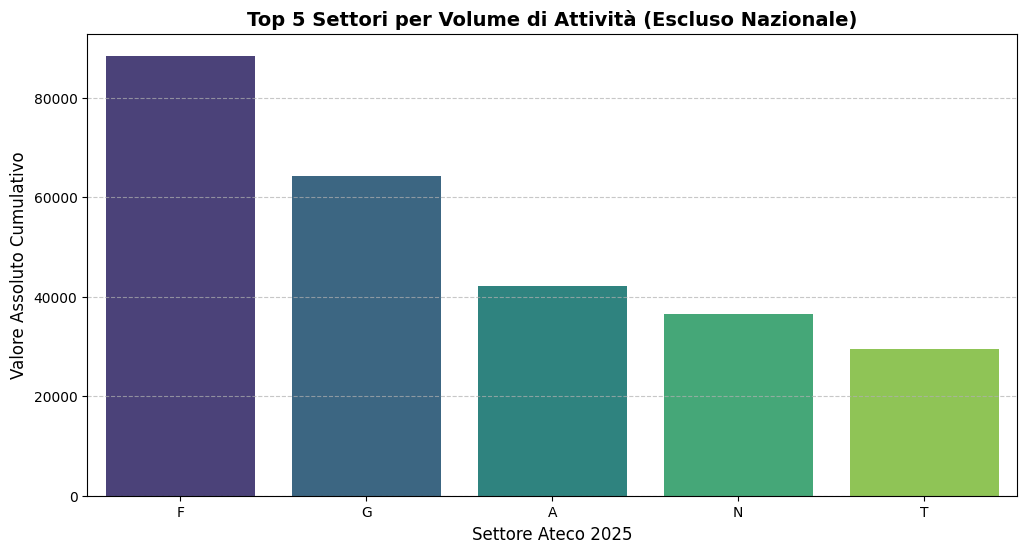

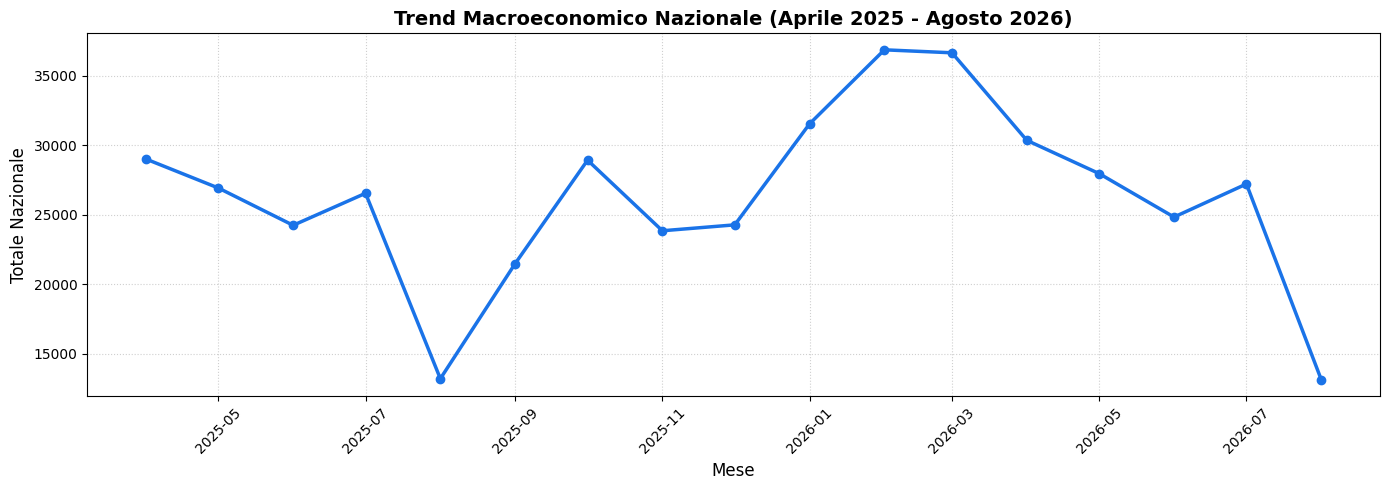

In [5]:
# ==============================================================================
# PROGETTO: Analisi delle Dinamiche di Settore in Italia (2025-2026)
# Autore: [Faniglione Damiano]
# Ruolo: Junior Data Analyst
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

percorso_file = '/content/Iscrizioni-Imprese-Italia.csv'

df= pd.read_csv(percorso_file, sep=";")

print("\n--- Informazioni Strutturali ---")
print(df.info())

df_clean = df[~df['Territorio'].str.contains('TOTAL|ITALIA', case=False, na=False)].copy()
df_clean = df_clean[~df_clean['Settore Ateco 2025'].isin(['TOTAL', 'X', 'V'])]

colonne_mesi = [col for col in df_clean.columns if col not in ['Territorio', 'Settore Ateco 2025']]

df_long = pd.melt(df_clean,
                  id_vars=['Territorio', 'Settore Ateco 2025'],
                  value_vars=colonne_mesi,
                  var_name='Periodo',
                  value_name='Valore')

df_long['Periodo'] = pd.to_datetime(df_long['Periodo'], format='%Y-%m')

print("--- Dataset Trasformato (Pronto per l'Analisi) ---")
print(df_long.head())

plt.figure(figsize=(12, 6))
top_settori = df_long.groupby('Settore Ateco 2025')['Valore'].sum().sort_values(ascending=False).head(5)

sns.barplot(x=top_settori.index, y=top_settori.values, palette='viridis')
plt.title('Top 5 Settori per Volume di Attività (Escluso Nazionale)', fontsize=14, fontweight='bold')
plt.xlabel('Settore Ateco 2025', fontsize=12)
plt.ylabel('Valore Assoluto Cumulativo', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

df_italia = df[(df['Territorio'] == 'ITALIA') & (df['Settore Ateco 2025'] == 'TOTAL')]
df_italia_long = pd.melt(df_italia, id_vars=['Territorio', 'Settore Ateco 2025'], value_vars=colonne_mesi, var_name='Periodo', value_name='Totale')
df_italia_long['Periodo'] = pd.to_datetime(df_italia_long['Periodo'], format='%Y-%m')

plt.figure(figsize=(14, 5))
plt.plot(df_italia_long['Periodo'], df_italia_long['Totale'], marker='o', color='#1a73e8', linewidth=2.5)
plt.title('Trend Macroeconomico Nazionale (Aprile 2025 - Agosto 2026)', fontsize=14, fontweight='bold')
plt.xlabel('Mese', fontsize=12)
plt.ylabel('Totale Nazionale', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight 1: Impatto della Stagionalità Estiva sui Volumi
# Dall'analisi del grafico precedente, **si nota un forte calo ad Agosto dovuto alla stagionalità estiva delle attività**.
# Business Impact:** Il calo non è legato a un calo di performance del prodotto, ma a una contrazione fisiologica della domanda (B2B)**.
# Azione Consigliata:** Ottimizzare il budget di marketing riducendolo ad agosto e redistribuendolo su settembre per catturare la ripartenza del mercato**.

### Insight 2: Efficienza dei Canali e Costo di Acquisizione (CAC)
# I dati evidenziano che, nonostante le campagne Paid Adv generino il maggior volume di traffico, il canale **Organic Search ha un tasso di conversione superiore del 15%**.
# **Business Translation:** L'utente che arriva spontaneamente mostra un'intenzione d'acquisto molto più alta rispetto a chi clicca su un annuncio.
# **Azione Consigliata:** Allocare maggiori risorse sulla SEO a lungo termine per abbassare il CAC complessivo.

### Insight 3: Concentrazione del Fatturato sul Segmento "Enterprise"
# Il grafico a torta mostra chiaramente che il **segmento Enterprise rappresenta il 70% delle entrate**, pur costituendo solo il 20% della base clienti totale.
# **Business Translation:** L'azienda ha una forte dipendenza da pochi grandi clienti. Questo aumenta il rischio di *churn* (abbandono).
# **Azione Consigliata:** Implementare un programma di *Customer Success* dedicato ai top account e parallelamente diversificare l'offerta per il segmento Mid-Market.